# Majors Survey Data Analysis

**Author:** Mustafa Erdem  
**Date:** June 4, 2026

## Objective

Analyze survey responses from students enrolled in computing courses between Fall 2020 and Fall 2024 to identify trends in academic interests, demographic distributions, enrollment motivations, and recruitment effectiveness through data cleaning, visualization, and exploratory analysis.

## Project Description

This project explores and cleans survey data collected from students enrolled in computing-related courses at County College of Morris (CCM) between Fall 2020 and Fall 2024. The analysis includes data quality assessment, data cleaning, exploratory data analysis (EDA), and the creation of a cleaned dataset for future use.

The purpose of this analysis is to examine patterns in student academic interests, demographic trends, enrollment motivations, and recruitment effectiveness through data-driven insights and visualizations.

## Research Questions

### 1. Which degree programs show the greatest increase or decrease in the percentage of student interest over the years based on survey responses?

### 2. How has the percentage distribution of female students by degree program changed over time?

### 3. How has the percentage distribution of male students by degree program changed over time?

### 4. Which factors had the greatest impact on students' decision to attend CCM?

### 5. How has the way students hear about CCM changed over the years?

## Technologies

- Python
- Pandas
- Matplotlib
- Jupyter Notebook

## Expected Deliverables

- Cleaned survey dataset (CSV)
- Exploratory data analysis
- Data visualizations
- Trend analysis
- Summary of key findings

In [33]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [34]:
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)

Pandas version: 3.0.2
Matplotlib version: 3.10.9


## Loading and Combining Survey Data

Survey datasets from Fall 2020 through Fall 2024 were loaded into separate DataFrames.  
These datasets were then combined into a single DataFrame so that trends across years could be analyzed.

Combining the datasets allows us to perform consistent data cleaning and analysis on the full survey dataset.

In [35]:
df2020 = pd.read_csv("Majors Survey Results - Fall 2020.csv")
df2021 = pd.read_csv("Majors Survey Results - Fall 2021.csv")
df2022 = pd.read_csv("Majors Survey Results - Fall 2022.csv")
df2023 = pd.read_csv("Majors Survey Results - Fall 2023.csv")
df2024 = pd.read_csv("Majors Survey Results - Fall 2024.csv")
df = pd.concat([df2020, df2021, df2022, df2023, df2024], ignore_index = True)

In [36]:
display(df) # before making any changes 

,Timestamp,Which course are you enrolled in?,How did you hear about County College of Morris? [CCM Web site],How did you hear about County College of Morris? [Social Media],How did you hear about County College of Morris? [Community Event],How did you hear about County College of Morris? [Family member or friend],How did you hear about County College of Morris? [Current CCM student],How did you hear about County College of Morris? [CCM Alumni],How did you hear about County College of Morris? [High School Teacher],How did you hear about County College of Morris? [High School Counselor],...,What motivated you to seek a computing degree/certificate at CCM? [Career Change],What motivated you to seek a computing degree/certificate at CCM? [Professional Development],What motivated you to seek a computing degree/certificate at CCM? [Job Displacement],What motivated you to seek a computing degree/certificate at CCM? [Relocation],What motivated you to seek a computing degree/certificate at CCM? [To keep current in tech industry],What motivated you to seek a computing degree/certificate at CCM? [IT Industry Certifications],What motivated you to seek a computing degree/certificate at CCM? [Financial],What motivated you to seek a computing degree/certificate at CCM? [Personal Enrichment],How did you hear about County College of Morris? [Home mailer],"Prior to applying to college, did you participate in any of the following events or activities at the County College of Morris and/or with the Department of Information Technologies, if at all? [Hour of Code]"
0,2020/07/28 3:21:36 PM EST,CMP 239 Internet & Web Page Design,Yes,Yes,No,Yes,Yes,No,No,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020/07/28 4:07:22 PM EST,CMP 239 Internet & Web Page Design,Yes,No,No,Yes,Yes,No,No,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020/07/28 8:12:47 PM EST,CMP 239 Internet & Web Page Design,Yes,No,No,Yes,Yes,No,No,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020/07/29 10:53:03 AM EST,CMP 239 Internet & Web Page Design,No,Yes,Yes,Yes,No,No,Yes,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020/07/29 4:26:21 PM EST,CMP 239 Internet & Web Page Design,Yes,No,No,Yes,No,No,No,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2024/09/22 6:32:46 PM AST,CMP 128 Computer Science I,Don't recall,Don't recall,Don't recall,Don't recall,Yes,Don't recall,Don't recall,Don't recall,...,No,Yes,No,Yes,Yes,Yes,Yes,Yes,NaN,NaN
1196,2024/09/22 8:51:18 PM AST,CMP 128 Computer Science I,Yes,No,No,Yes,No,No,No,Yes,...,No,Yes,No,No,No,No,No,No,NaN,NaN
1197,2024/09/22 9:17:23 PM AST,CMP 128 Computer Science I,Yes,Don't recall,No,No,No,No,Yes,Yes,...,No,No,No,No,No,No,Yes,Yes,NaN,NaN
1198,2024/09/22 11:07:28 PM AST,CMP 128 Computer Science I,Yes,No,No,Yes,Yes,Yes,Yes,No,...,No,Yes,No,No,Yes,No,No,Yes,NaN,NaN


In [37]:
print(df.columns)  # Display all column names before filtering to identify which columns should be selected.

Index(['Timestamp', 'Which course are you enrolled in?',
       'How did you hear about County College of Morris? [CCM Web site]',
       'How did you hear about County College of Morris? [Social Media]',
       'How did you hear about County College of Morris? [Community Event]',
       'How did you hear about County College of Morris? [Family member or friend]',
       'How did you hear about County College of Morris? [Current CCM student]',
       'How did you hear about County College of Morris? [CCM Alumni]',
       'How did you hear about County College of Morris? [High School Teacher]',
       'How did you hear about County College of Morris? [High School Counselor]',
       'How did you hear about County College of Morris? [In-app advertisement]',
       'How did you hear about County College of Morris? [Employer]',
       'How did you hear about County College of Morris? [Billboard]',
       'How did you hear about County College of Morris? [Television]',
       'How did you h

## Filtering Relevant Columns
In this step, the dataset is filtered to keep only the columns that are relevant to the analysis. 
A list of patterns is used to identify columns related to the survey questions needed for this project, 
such as gender, degree program, factors influencing the decision to attend CCM, and how students heard about CCM. 
All other columns are excluded from the dataset.
## Removed Survey Questions
- Which course are you enrolled in?
- Prior to applying to college, did you participate in any of the following events or activities at the County College of Morris and/or with the Department of Information Technologies, if at all?
- To what extent did the following activities or experience impact your decision to enroll in an computing course at CCM?
- Did you receive information about the CCM computing programs from any of the following sources?
- Was a computing major/certificate your first choice, or did you change majors from a different CCM program? If you changed majors, indicate what your first major was.
- On a scale of 1 to 5, with 1 being not at all interested and 5 being extremely interested, how interested are you in taking more computing classes?
- Please explain your answer to the question above.  Why or why not would you be interested in taking another computing class?
- Race/ethnicity
- Prior to applying to college, did you participate in any of the following events or activities at the County College of Morris and/or with the Department of Information Technologies, if at all?
- What motivated you to seek a computing degree/certificate at CCM?

In [38]:
patterns = [
    "Timestamp",
    "How did you hear about County College of Morris?",
    "To what extent did the following impact your decision to attend County College of Morris?",
    "What degree program are you currently enrolled in?",
    "Gender"
]
mask = df.columns.str.contains('|'.join(patterns), case=False, regex=True)
df = df.loc[:, mask]

# The "Home mailer" column was originally located at the end of the dataset.To keep related survey questions grouped together, the column is repositioned in the DataFrame.
col = df.pop('How did you hear about County College of Morris? [Home mailer]') # Remove the column so it can be repositioned with the other related "How did you hear about CCM?" columns. 
df.insert(1, 'How did you hear about County College of Morris? [Home mailer]', col) # Insert the column at position 1 to keep it grouped with the related survey questions.


## Renaming Columns

In this section, I renamed several columns to make them shorter, clearer, and easier to work with in Python. 

The original column names were long and contained spaces and special characters, which can make data analysis more difficult. I converted the names to lowercase and used underscores to separate words. This follows the project requirement and improves readability and consistency in the dataset.

In [39]:
df.rename(columns={
       'Timestamp' : "date",
        "To what extent did the following impact your decision to attend County College of Morris? [Ability to transfer CCM credits to a 4-year school]" : "decision_impact_ability_to_transfer",
        'What degree program are you currently enrolled in?' : "major"
}, inplace=True)

## Cleaning and Standardizing Column Names

Many of the survey column names were very long because they included full survey questions and brackets. To make the dataset easier to work with, I used string replacement to shorten and standardize these column names.

I replaced long question text with shorter prefixes such as heard_from_, decision_impact_. I also removed brackets, spaces, and converted all column names to lowercase with underscores. This improves readability, ensures consistency, and follows the project requirement for clean column names.

In [40]:
df.columns = df.columns.str.replace('How did you hear about County College of Morris? [', "@")
df.columns = df.columns.str.replace('To what extent did the following impact your decision to attend County College of Morris? [' , "decision_impact_").str.replace("]", "").str.replace(" ", "_").str.lower()


In [41]:
df.isna().sum()  # Display the number of missing values in each column

date                                                         0
@home_mailer                                               740
@ccm_web_site                                                0
@social_media                                                0
@community_event                                             0
@family_member_or_friend                                     0
@current_ccm_student                                         0
@ccm_alumni                                                  0
@high_school_teacher                                         0
@high_school_counselor                                       0
@in-app_advertisement                                        0
@employer                                                    0
@billboard                                                   0
@television                                                  0
@radio                                                       0
@other                                                 

## Handling Missing Values

In this section, I replaced missing values in several survey columns with appropriate labels.

For columns related to decision impact, I replaced missing values with "No Impact" to indicate that the factor did not influence the student's decision. 

For heard_from columns, I replaced missing values with "No" to indicate that the student did not hear information from those sources.


In [42]:
df.loc[: , df.columns[df.columns.str.contains("decision_impact")]] = df.loc[: , df.columns[df.columns.str.contains("decision_impact")]].fillna("No Impact")

df.loc[: , df.columns[df.columns.str.contains("heard_from")]] = df.loc[: , df.columns[df.columns.str.contains("heard_from")]].fillna("No")


In [43]:
df.isna().sum() # no missing data

date                                                         0
@home_mailer                                               740
@ccm_web_site                                                0
@social_media                                                0
@community_event                                             0
@family_member_or_friend                                     0
@current_ccm_student                                         0
@ccm_alumni                                                  0
@high_school_teacher                                         0
@high_school_counselor                                       0
@in-app_advertisement                                        0
@employer                                                    0
@billboard                                                   0
@television                                                  0
@radio                                                       0
@other                                                 

In [44]:
display(df) # after changes 

,date,@home_mailer,@ccm_web_site,@social_media,@community_event,@family_member_or_friend,@current_ccm_student,@ccm_alumni,@high_school_teacher,@high_school_counselor,...,decision_impact_scholarships,decision_impact_small_class_sizes,decision_impact_extra-curricular_opportunities,decision_impact_accepted_my_transfer_credits,decision_impact_negative_experience_at_another_college,decision_impact_nj_stars_program,decision_impact_ability_to_transfer,decision_impact_get_college_credit_while_in_high_school,major,gender
0,2020/07/28 3:21:36 PM EST,NaN,Yes,Yes,No,Yes,Yes,No,No,No,...,No Impact,No Impact,No Impact,No Impact,No Impact,No Impact,High Impact,No Impact,"Computer Science, Associate of Science",Man
1,2020/07/28 4:07:22 PM EST,NaN,Yes,No,No,Yes,Yes,No,No,No,...,No Impact,No Impact,No Impact,High Impact,No Impact,No Impact,High Impact,No Impact,"Information Technology, Applied Associate of S...",Woman
2,2020/07/28 8:12:47 PM EST,NaN,Yes,No,No,Yes,Yes,No,No,No,...,No Impact,No Impact,No Impact,No Impact,No Impact,No Impact,High Impact,No Impact,"Information Technology, Applied Associate of S...",Man
3,2020/07/29 10:53:03 AM EST,NaN,No,Yes,Yes,Yes,No,No,Yes,Yes,...,No Impact,No Impact,No Impact,No Impact,No Impact,No Impact,High Impact,No Impact,Non Degree seeking,Woman
4,2020/07/29 4:26:21 PM EST,NaN,Yes,No,No,Yes,No,No,No,No,...,No Impact,Some Impact,Some Impact,High Impact,No Impact,No Impact,High Impact,No Impact,"Computer Science, Associate of Science",Man
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2024/09/22 6:32:46 PM AST,NaN,Don't recall,Don't recall,Don't recall,Don't recall,Yes,Don't recall,Don't recall,Don't recall,...,No Impact,No Impact,No Impact,No Impact,High Impact,No Impact,No Impact,No Impact,Information Technology,Man
1196,2024/09/22 8:51:18 PM AST,NaN,Yes,No,No,Yes,No,No,No,Yes,...,No Impact,No Impact,No Impact,No Impact,No Impact,No Impact,No Impact,No Impact,Information Technology,Man
1197,2024/09/22 9:17:23 PM AST,NaN,Yes,Don't recall,No,No,No,No,Yes,Yes,...,Some Impact,No Impact,No Impact,No Impact,No Impact,No Impact,Some Impact,No Impact,Computer Science,Man
1198,2024/09/22 11:07:28 PM AST,NaN,Yes,No,No,Yes,Yes,Yes,Yes,No,...,No Impact,No Impact,No Impact,No Impact,No Impact,No Impact,Some Impact,No Impact,Computer Science,Man


## Inspecting Unique Majors

This step extracts all unique values from the `major` column. 
- `.str.lower()` standardizes capitalization so that variations like "Computer Science" and "computer science" are treated the same.  
- `.str.strip()` removes any extra spaces at the beginning or end of the strings.  
- `set()` ensures that only unique values are kept.  

`print()` displays the result so I can inspect the list of majors and identify inconsistencies before cleaning and categorizing them.

In [45]:
uniq_majors = list(set(df.loc[: , "major"].str.lower().str.strip()))
display(uniq_majors)

['sharetime csip program',
 'dual enrollment',
 'mechanical technology major',
 'administrative business',
 'electronics technolgies engineering',
 'edam student',
 'information security certificate of achievement',
 'mechanical engineering tech',
 'minoring in computer science',
 'mechanical/electrical engineer',
 'information technology',
 'libral arts',
 'undecided',
 'business admin',
 'business management',
 'graphic arts',
 'electronic engineering technology',
 'cis game development option, applied associate of science',
 'engineering',
 'mec tech',
 'computer science and digital media technology',
 'cybersecurity',
 'gaining college credits for high school',
 'mechanical engineering and technology',
 'graphics design',
 'business administration',
 'radiography',
 'cyberseucirty',
 'elec engineering tech',
 'data science',
 'biology environmental track',
 'mathematics',
 'finance/business',
 'mechanical engineer tech',
 'challenger program',
 'electronics engineering',
 'informat

### Categorizing Majors Using Keyword Matching

To ensure majors are grouped accurately, a dictionary of categories was created where each category contains a list of related keywords. Each unique major is checked against these keywords to determine the best match.

A loop assigns each major to the **first matching category**, preventing duplicates or conflicting classifications. Majors that do not match any predefined keywords are placed in the **“Other”** category to avoid misclassification.

This approach standardizes inconsistent or differently formatted major names and reduces errors caused by variations in spelling or wording.

In [46]:
categories = {
    'High School Student': ['dual enrollment', 'visiting student','highschool', 'high school', 'edam', 'time' , 'sharetime', 'academy', 'challenger', 'votech infosec'],
    'Engineering': ['engineering','met', 'mech', "mec tech", 'mechanical engineering technology','electronic', 'electrical', 'electrical engineering', 'civil engineering', 'engineering science', 'electronic engineering technology'],
    'Computer Science / IT' : ['computer science', 'information technology', 'data science', 'digital media technology', 'cybersecurity', 'cyberseucirty'],
    'Business / Economics': ['business', 'economic','business administration', 'finance', 'business management'],
    'Health / Nursing': ['nursing', 'radiography', 'early childhood education'],
    'Arts / Design': ['art','graphic', 'design','graphic design', 'music recording', 'graphic arts', 'digital media technology'],
    'Science / Math': ['biology', 'chemistry', 'math', 'mathematics', 'mathematics and science', 'associate degree in mathematics', 'bio'],
    'Non-major': ['undecided', 'non degree seeking', 'dont have one'],
    'CIS / Game Developer' : [ 'game', 'cis' ],
    "Other" : ""
}
categories["Other"] = []

debug_major_dict = dict()

for major in uniq_majors:
    found = False
    for category, majors_list in categories.items():
        
        if category == "Other":
            continue
        if any(keyword in major for keyword in majors_list):
            if category not in debug_major_dict:
                debug_major_dict[category] = []
            debug_major_dict[category].append(major)
            found = True
            break  
    if not found:
        debug_major_dict.setdefault("Other", []).append(major)
df_debug = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in debug_major_dict.items()]))
display(df_debug)

,High School Student,Engineering,Business / Economics,Other,Computer Science / IT,Arts / Design,Non-major,CIS / Game Developer,Health / Nursing,Science / Math
0,sharetime csip program,mechanical technology major,administrative business,information security certificate of achievement,minoring in computer science,libral arts,undecided,"cis game development option, applied associate...",radiography,biology environmental track
1,dual enrollment,electronics technolgies engineering,business admin,web development certificate of achievement,information technology,graphic arts,non degree seeking,cis game development option,nursing,mathematics
2,edam student,mechanical engineering tech,business management,didn't send professor screenshot,computer science and digital media technology,graphics design,dont have one,NaN,"nursing, associate of science","mathematics option, applied associate of science"
3,gaining college credits for high school,mechanical/electrical engineer,business administration,"technical studies, applied associate of science",cybersecurity,music recording,NaN,NaN,early childhood education,chemistry
4,challenger program,electronic engineering technology,finance/business,associate's degree,cyberseucirty,graphic design,NaN,NaN,NaN,math-education specialization
5,sharetime(edam),engineering,finance,communications,data science,liberal arts,NaN,NaN,NaN,mathematics associate of science
6,edam share time,mec tech,business,morris tech,information technology & info security certifi...,associates of fine arts concentration architec...,NaN,NaN,NaN,mathematics and science
7,edam sharetime,mechanical engineering and technology,business professional,data analytics certificate of achievement,information technology and information securit...,liberal arts program,NaN,NaN,NaN,associate degree in mathematics
8,visiting student,elec engineering tech,"business admin, might change to compsci :)",political science,"information technology, applied associate of s...",culinary arts and science,NaN,NaN,NaN,biology
9,not enrolled in a degree program (votech infosec),mechanical engineer tech,business and marketing,fire science technology,"digital media technology, applied associate of...",liberal arts major,NaN,NaN,NaN,bio


## Categorizing Majors

In this step, we standardize and categorize the entries in the `major` column. 

1. **Cleaning the text:**  
   - `str.lower()` converts all text to lowercase so variations in capitalization (e.g., "Computer Science" vs "computer science") are treated the same.  
   - `str.strip()` removes extra spaces at the beginning or end of the strings.

2. **Mapping to categories:**  
   - The `categorize_major` function compares each major to a list of keywords defined in the `categories` dictionary.  
   - If a keyword is found in the major, it is assigned the corresponding category key.  
   - If no keywords match, the major is assigned `"Other"`.

3. **Applying the categorization:**  
   - `.apply(lambda x: categorize_major(x, categories))` runs this function on every row in the `major` column.

4. **Inspecting results:**  
   - `set(df['major'].str.lower())` shows all unique categories after mapping, ensuring that majors have been grouped correctly.

In [47]:
def categorize_major(major, categories):
    major = str(major).lower().strip()

    for category, majors_list in categories.items():
        if any(keyword in major for keyword in majors_list):
            return category

    return "Other"

df['major'] = df['major'].apply(lambda x: categorize_major(x, categories))
uniq_majors = set(df.loc[: , "major"].str.lower())
print(uniq_majors)

{'other', 'business / economics', 'high school student', 'cis / game developer', 'science / math', 'health / nursing', 'arts / design', 'engineering', 'non-major', 'computer science / it'}


## Saving Cleaned Dataset

The cleaned dataset was saved as a new CSV file for future analysis.

In [48]:
df.to_csv('Clean Majors Survey Results - Fall 2020-2024.csv', index=False)

### Analyzing Changes in Student Interest by Degree Program

To identify which degree programs show the greatest increase or decrease in student interest over the years, we first calculate the percentage of students in each major for each year. 

This is done by:
1. Grouping the data by `year` and `major` to count responses.
2. Converting these counts into percentages of total responses per year.
3. Comparing percentages across years to find the programs with the largest increase or decrease.

The resulting table and/or visualization clearly highlights trends in student interest over time.

### Extracting Year and Counting Majors

The `date` column is converted to a datetime format after removing the timezone from the string. The year is then extracted using `.dt.year` and stored in a new column called `year`.

Next, the data is grouped by `year` and `major` to count how many responses each major received per year. This helps analyze how student interest in different majors changes over time.

In [49]:
df["year"] = pd.to_datetime(
    df["date"].str.replace(r" [A-Z]{3,4}$", "", regex=True),
    format="%Y/%m/%d %I:%M:%S %p",
    errors="coerce"
).dt.year
df["year"] = df["year"].astype(int)
major_counts = df.groupby(["year", "major"]).size().reset_index(name = "count")
display(major_counts)

,year,major,count
0,2020,Arts / Design,5
1,2020,Business / Economics,13
2,2020,CIS / Game Developer,15
3,2020,Computer Science / IT,151
4,2020,Engineering,34
5,2020,Health / Nursing,2
6,2020,High School Student,33
7,2020,Non-major,24
8,2020,Other,15
9,2020,Science / Math,6


In [50]:
# Calculate percentage of students in each major per year
major_percent = major_counts.copy()
major_percent["percent"] = major_percent.groupby("year")["count"].transform(lambda x: x / x.sum() * 100)

pivot = major_percent.pivot(index="year", columns="major", values="percent")
pivot = pivot.fillna(0)
display(pivot)


major,Arts / Design,Business / Economics,CIS / Game Developer,Computer Science / IT,Engineering,Health / Nursing,High School Student,Non-major,Other,Science / Math
year,,,,,,,,,,
2020,1.677852,4.362416,5.033557,50.671141,11.409396,0.671141,11.073826,8.053691,5.033557,2.013423
2021,2.448980,3.673469,2.040816,59.591837,8.979592,0.408163,11.836735,6.530612,2.857143,1.632653
2022,1.834862,5.045872,4.128440,60.091743,6.880734,0.458716,10.091743,5.963303,4.128440,1.376147
2023,0.826446,1.652893,4.132231,58.264463,7.851240,0.413223,11.983471,7.438017,7.024793,0.413223
2024,2.030457,4.060914,3.553299,55.329949,11.675127,0.000000,6.091371,6.598985,10.152284,0.507614


In [51]:
# Get the percentage values from the latest year and the earliest year
# then compute the percent change between them
change = (pivot.loc[pivot.index.max()] - pivot.loc[pivot.index.min()]) / pivot.loc[pivot.index.min()] * 100

# Sort the results so we can easily see which majors had the largest increase
# and which had the largest decrease in student interest
change.sort_values()


major
Health / Nursing        -100.000000
Science / Math           -74.788494
High School Student      -44.993078
CIS / Game Developer     -29.407783
Non-major                -18.062606
Business / Economics      -6.911363
Engineering                2.329053
Computer Science / IT      9.194204
Arts / Design             21.015228
Other                    101.692047
dtype: float64

The line chart shows how student interest in each major changed over time. 
Each line represents a different major, and the points indicate the percentage of students for each year. 
From the chart, we can observe which programs increased in popularity, which decreased, and any trends or fluctuations in student interest across the survey period.
According to the chart, **Other/Certificate** had the greatest increase (+101.7%), while **Health / Nursing** had the greatest decrease (−100%).

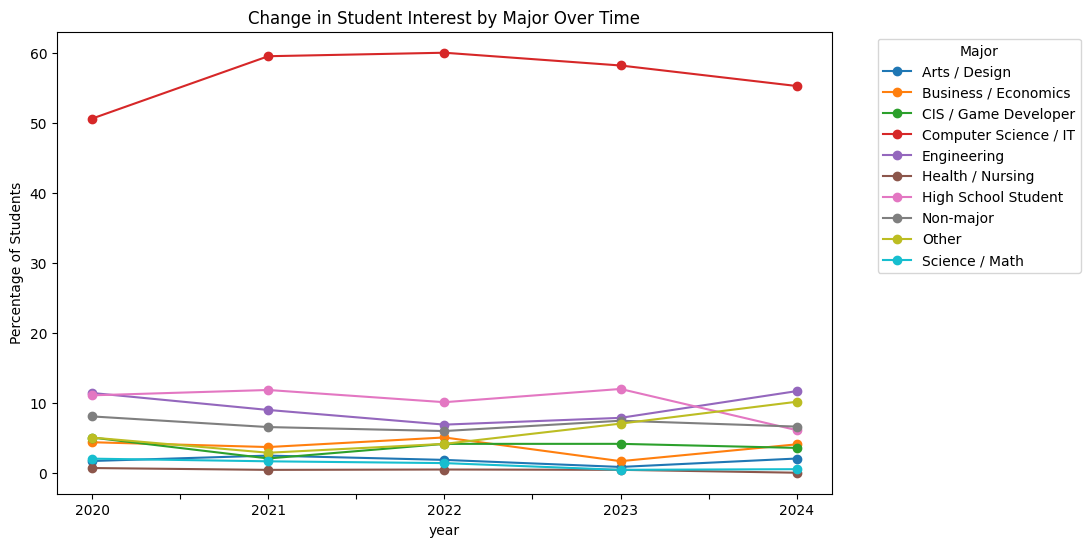

str


In [52]:
pivot.index = pivot.index.astype(str)
pivot.plot(kind="line", marker="o", figsize=(10,6))
plt.ylabel("Percentage of Students")
plt.title("Change in Student Interest by Major Over Time")
plt.legend(title="Major", bbox_to_anchor=(1.05, 1), loc='upper left')


plt.show()
print(pivot.index.dtype)

## Female Students by Degree Program

This section analyzes the distribution of female students across different degree programs over time.

First, the dataset is filtered to include only responses from students who identified their gender as "Woman". The number of female students in each degree program is then counted for each year.

Next, the percentage distribution of female students by major is calculated within each year. This is done by dividing the number of female students in each program by the total number of female students in that year.

Finally, the results are reshaped into a pivot table where:
- Each row represents a year
- Each column represents a degree program
- Each value represents the percentage of female students interested in that program

This table allows us to observe how female student interest in different degree programs has changed over time.

In [53]:
df["gender"] = df["gender"].apply(lambda x: x if x in ["Man", "Woman"] else "Other Genders")
genders = df.groupby(["year", "gender"]).size().reset_index(name = "count")
display(genders)

,year,gender,count
0,2020,Man,219
1,2020,Other Genders,13
2,2020,Woman,66
3,2021,Man,197
4,2021,Other Genders,6
5,2021,Woman,42
6,2022,Man,163
7,2022,Other Genders,13
8,2022,Woman,42
9,2023,Man,193


### Counting Students by Year, Gender, and Major

The dataset is grouped by **year**, **gender**, and **major**, and the number of students in each combination is counted.  

This allows analysis of how gender distribution varies across different majors over time.

In [54]:
gender_counts = df.groupby(["year", "gender", "major"]).size().reset_index(name = "count")
display(gender_counts)

,year,gender,major,count
0,2020,Man,Arts / Design,4
1,2020,Man,Business / Economics,5
2,2020,Man,CIS / Game Developer,11
3,2020,Man,Computer Science / IT,118
4,2020,Man,Engineering,29
...,...,...,...,...
99,2024,Woman,Computer Science / IT,21
100,2024,Woman,High School Student,4
101,2024,Woman,Non-major,2
102,2024,Woman,Other,3


### Female Students by Year and Major

The data is filtered to include only **female students**, then grouped by **year** and **major** to count the number of female students in each category.  

This allows analysis of trends in female enrollment across different majors over time.

In [55]:


female_counts = df[df["gender"] == "Woman"]

female_counts = female_counts.groupby(["year", "major"]).size().reset_index(name="count")
display(female_counts)

,year,major,count
0,2020,Arts / Design,1
1,2020,Business / Economics,8
2,2020,CIS / Game Developer,2
3,2020,Computer Science / IT,26
4,2020,Engineering,4
5,2020,Health / Nursing,2
6,2020,High School Student,6
7,2020,Non-major,11
8,2020,Other,3
9,2020,Science / Math,3


In [56]:
# Calculate percentage of students in each major per year
female_counts["percentage"] = female_counts.groupby("year")["count"].transform(lambda x: x / x.sum() * 100)

female_percent = female_counts.pivot(index="year", columns="major", values="percentage")
female_percent = female_percent.fillna(0)
display(female_percent)

major,Arts / Design,Business / Economics,CIS / Game Developer,Computer Science / IT,Engineering,Health / Nursing,High School Student,Non-major,Other,Science / Math
year,,,,,,,,,,
2020,1.515152,12.121212,3.030303,39.393939,6.060606,3.030303,9.090909,16.666667,4.545455,4.545455
2021,7.142857,0.000000,2.380952,38.095238,0.000000,0.000000,26.190476,23.809524,0.000000,2.380952
2022,2.380952,7.142857,7.142857,50.000000,2.380952,2.380952,14.285714,2.380952,9.523810,2.380952
2023,2.564103,5.128205,0.000000,51.282051,2.564103,2.564103,20.512821,5.128205,10.256410,0.000000
2024,3.030303,3.030303,0.000000,63.636364,0.000000,0.000000,12.121212,6.060606,9.090909,3.030303


<Figure size 1200x600 with 0 Axes>

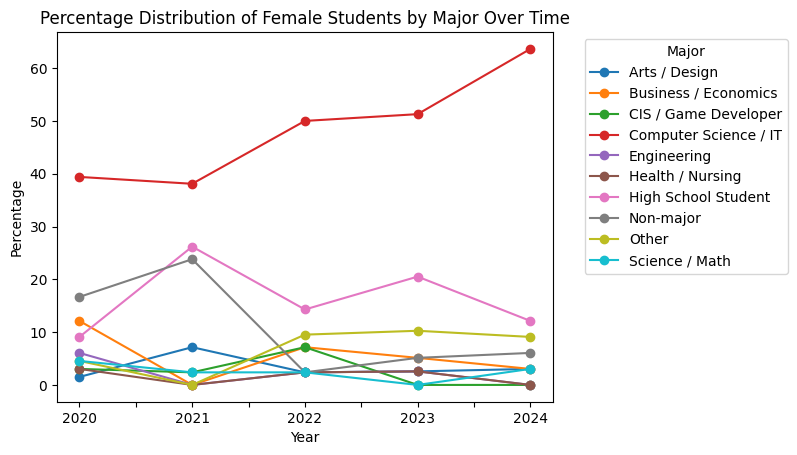

In [57]:
female_percent.index = female_percent.index.astype(str)
plt.figure(figsize=(12,6))

female_percent.plot(kind="line", marker="o")

plt.title("Percentage Distribution of Female Students by Major Over Time")
plt.xlabel("Year")
plt.ylabel("Percentage")

plt.legend(title="Major", bbox_to_anchor=(1.05, 1), loc='upper left')

#plt.tight_layout()
plt.show()

## Male Students by Degree Program

This section analyzes the distribution of Male students across different degree programs over time.

First, the dataset is filtered to include only responses from students who identified their gender as "Man". The number of male students in each degree program is then counted for each year.

Next, the percentage distribution of female students by major is calculated within each year. This is done by dividing the number of male students in each program by the total number of female students in that year.

Finally, the results are reshaped into a pivot table where:
- Each row represents a year
- Each column represents a degree program
- Each value represents the percentage of female students interested in that program

This table allows us to observe how male student interest in different degree programs has changed over time.

In [58]:
male_counts = df[df["gender"] == "Man"]

male_counts = male_counts.groupby(["year", "major"]).size().reset_index(name="count")

male_counts["percentage"] = male_counts.groupby("year")["count"].transform(lambda x: x / x.sum() * 100)

male_percent = male_counts.pivot(index="year", columns="major", values="percentage")

male_percent = male_percent.fillna(0)

display(male_percent)


major,Arts / Design,Business / Economics,CIS / Game Developer,Computer Science / IT,Engineering,Health / Nursing,High School Student,Non-major,Other,Science / Math
year,,,,,,,,,,
2020,1.826484,2.283105,5.022831,53.881279,13.242009,0.000000,11.415525,5.936073,5.479452,0.913242
2021,1.522843,4.568528,2.030457,63.959391,10.659898,0.507614,9.137056,3.045685,3.553299,1.015228
2022,1.840491,4.294479,3.067485,62.576687,7.975460,0.000000,8.588957,7.361963,3.067485,1.226994
2023,0.000000,1.036269,5.181347,59.585492,9.326425,0.000000,10.362694,7.253886,6.735751,0.518135
2024,1.234568,4.320988,4.320988,53.703704,14.197531,0.000000,4.938272,6.790123,10.493827,0.000000


<Figure size 1200x600 with 0 Axes>

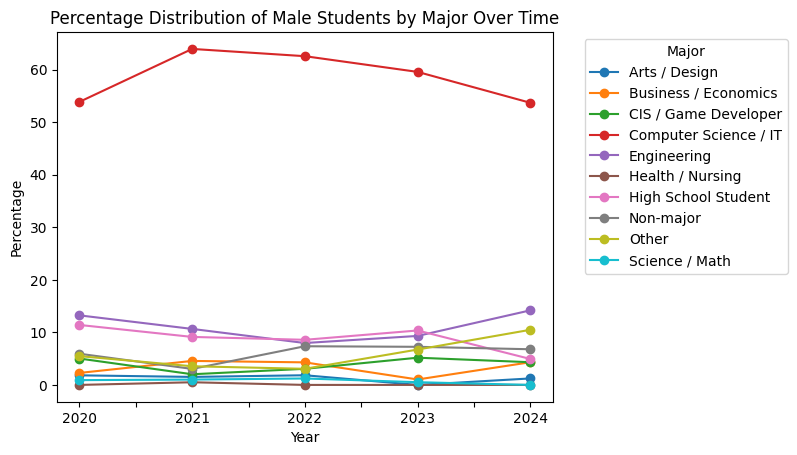

In [59]:
male_percent.index = male_percent.index.astype(str)
plt.figure(figsize=(12,6))   
male_percent.plot(kind="line", marker="o")

plt.title("Percentage Distribution of Male Students by Major Over Time")
plt.xlabel("Year")
plt.ylabel("Percentage")

plt.legend(title="Major", bbox_to_anchor=(1.05, 1), loc='upper left')


plt.show()

## Factors Influencing Students' Decision to Attend CCM

To analyze which factors had the greatest impact on students' decisions, survey responses were converted into numerical values:

- No Impact = 0
- Some Impact = 1
- High Impact = 2

The average score for each factor was then calculated across all responses.  
Higher average scores indicate factors that had a stronger influence on students' decisions.

In [60]:
impact_map = {
    "No Impact": 0,
    "Some Impact": 1,
    "High Impact": 2
}

impact_cols = df.filter(like="decision_impact_").columns

df[impact_cols] = df[impact_cols].replace(impact_map).astype(int)
impact_scores = df[impact_cols].mean().sort_values(ascending=False)
display(impact_scores)

decision_impact_location/convenience                       1.453333
decision_impact_affordable_cost                            1.415000
decision_impact_ability_to_transfer                        1.408333
decision_impact_choice_of_programs                         1.315833
decision_impact_college_reputation                         0.933333
decision_impact_family/friend_referral                     0.849167
decision_impact_financial_aid                              0.811667
decision_impact_online_offerings                           0.709167
decision_impact_small_class_sizes                          0.680833
decision_impact_scholarships                               0.603333
decision_impact_accepted_my_transfer_credits               0.560000
decision_impact_get_college_credit_while_in_high_school    0.525000
decision_impact_faculty/staff                              0.474167
decision_impact_extra-curricular_opportunities             0.450833
decision_impact_negative_experience_at_another_c

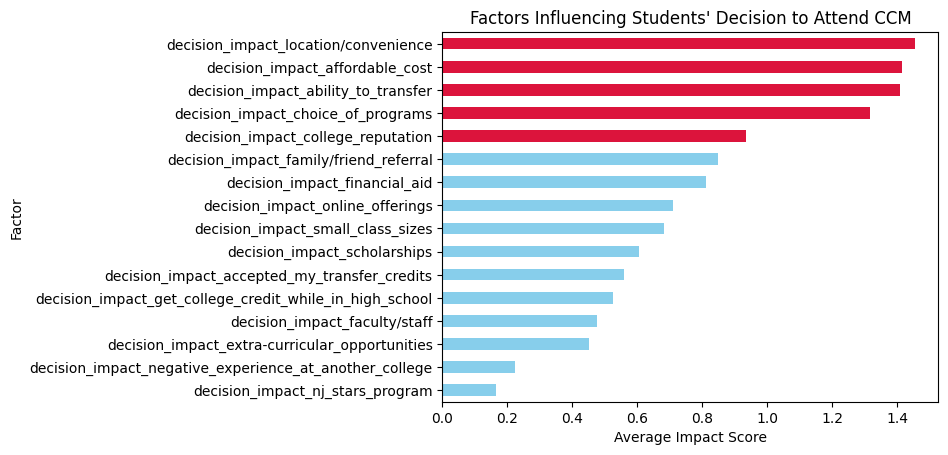

In [61]:
sorted_scores = impact_scores.sort_values()


colors = ['skyblue'] * len(sorted_scores)
for i in range(-5, 0):  # last 5 = highest values
    colors[i] = 'crimson'


sorted_scores.plot(kind="barh", color=colors)

plt.title("Factors Influencing Students' Decision to Attend CCM")
plt.ylabel("Factor")
plt.xlabel("Average Impact Score")

plt.show()

### How Students Heard About CCM

To analyze how students learned about CCM, all columns beginning with `@` were selected.

For each year, the number of students who answered "Yes" was counted and divided by the total number of students in that year. This produced the percentage of students who heard about CCM from each source.

Over the years, the most common way students hear about CCM has remained through family members or friends, consistently around 69–77%. The CCM website has become increasingly important, reaching over 42% in 2024. Meanwhile, influence from high school teachers and counselors has gradually decreased, and traditional advertising methods such as billboards, television, and radio have declined significantly. Social media has remained relatively stable but has not become the dominant source.

In [62]:
heard_colmns = df.filter(like="@")

heard_year = (heard_colmns == "Yes").groupby(df["year"]).sum()

students_per_year = df.groupby("year").size()
heard_percent = heard_year.div(students_per_year, axis=0) * 100
display(heard_percent)

,@home_mailer,@ccm_web_site,@social_media,@community_event,@family_member_or_friend,@current_ccm_student,@ccm_alumni,@high_school_teacher,@high_school_counselor,@in-app_advertisement,@employer,@billboard,@television,@radio,@other
year,,,,,,,,,,,,,,,
2020,0.000000,38.926174,20.469799,19.798658,72.818792,50.000000,26.174497,50.000000,55.033557,3.691275,3.355705,17.114094,5.369128,3.020134,12.416107
2021,0.000000,36.326531,15.510204,19.183673,77.142857,37.142857,28.979592,51.020408,57.959184,2.857143,3.265306,9.387755,3.673469,2.448980,13.061224
2022,10.550459,33.486239,16.055046,13.302752,72.018349,39.908257,27.981651,49.541284,51.376147,1.834862,1.834862,6.422018,2.752294,0.000000,11.926606
2023,16.528926,35.537190,21.487603,19.421488,69.421488,42.148760,29.752066,46.280992,52.066116,4.132231,5.785124,8.264463,3.719008,2.479339,14.876033
2024,0.000000,42.131980,15.736041,18.781726,70.558376,37.563452,21.827411,40.101523,47.208122,2.538071,5.583756,8.629442,4.568528,1.522843,10.659898


# Data Grouping for Analysis
To simplify the visualization, individual survey responses were grouped into broader categories. Word-of-mouth includes family, friends, current students, and alumni. School influence combines high school teachers and counselors. Online sources include the CCM website and social media. Advertising includes television, radio, billboards, in-app ads, and home mailers. Community events and other responses were grouped separately. This makes it easier to compare major sources of student awareness over time.

In [63]:
heard_percent["Word_of_Mouth"] = heard_percent[
    ["@family_member_or_friend", "@current_ccm_student", "@ccm_alumni"]
].mean(axis=1)

heard_percent["High_School_Guidance"] = heard_percent[
    ["@high_school_teacher", "@high_school_counselor"]
].mean(axis=1)

heard_percent["Online"] = heard_percent[
    ["@ccm_web_site", "@social_media"]
].mean(axis=1)

heard_percent["Advertising"] = heard_percent[
    ["@television", "@radio", "@billboard", "@in-app_advertisement", "@home_mailer"]
].mean(axis=1)

heard_percent["Other"] = heard_percent[
    ["@other", "@community_event"]
].mean(axis=1)
plot_data = heard_percent[[
    "Word_of_Mouth",
    "High_School_Guidance",
    "Online",
    "Advertising",
    "Other"
]]


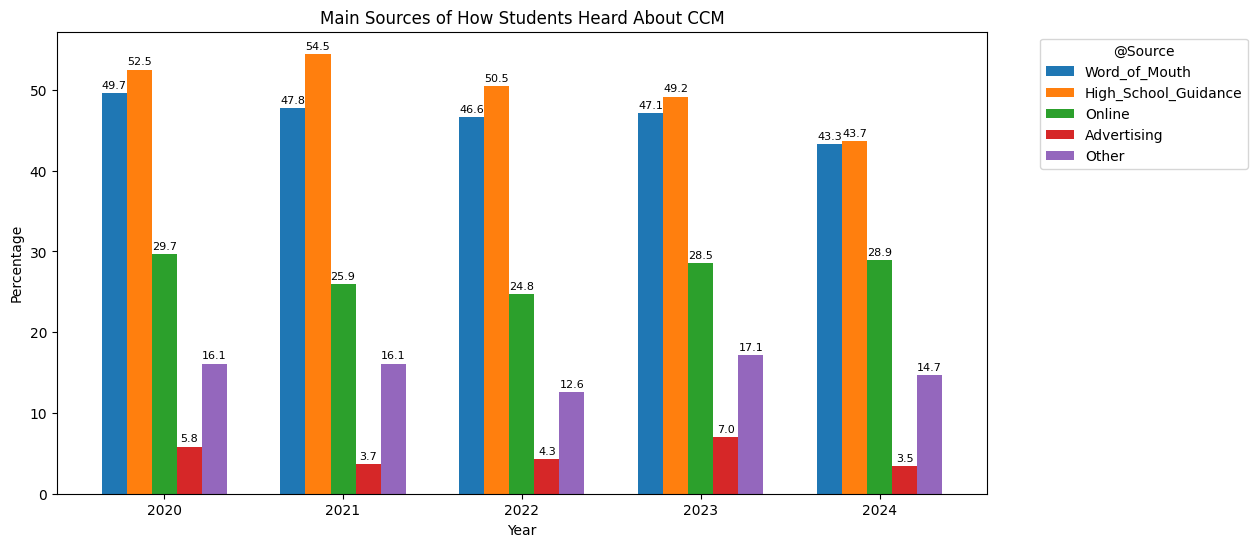

In [64]:
ax = plot_data.plot(kind="bar", figsize=(12,6), width=0.7)

plt.title("Main Sources of How Students Heard About CCM")
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.legend(title="@Source", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=8, padding=2)

plt.show()

### Conclusion

This analysis examined survey data from 2020 through 2024 to understand trends in student interest in degree programs, gender distribution by major, factors influencing students’ decisions to attend CCM, and how students learned about the college.

### Degree Program Interest
Computer Science / IT remained the most popular major across all years, consistently representing the largest share of students and staying above 50% throughout the period. CIS / Game Developer also maintained a steady presence, though at much lower levels, indicating continued but smaller interest in that field. Engineering showed moderate growth over time and became slightly more prominent in later years. Arts / Design and Business / Economics remained relatively low with minor fluctuations and no strong upward trend. Other categories, including Health / Nursing and Science / Math, stayed minimal or declined over time. Overall, student interest is heavily concentrated in Computer Science / IT, with Engineering and CIS / Game Developer as secondary technical pathways.

### Gender Distribution
Among female students, Computer Science / IT interest grew significantly, reaching 63.6% in 2024, while Engineering and Health / Nursing remained low. Male students also favored Computer Science / IT, peaking around 63.9% in 2021, with Engineering participation gradually increasing to 14.2% in 2024. The "Other" and "Non-major" categories showed more variation across years for both genders.

### Factors Influencing Decisions
The most influential factors for students choosing CCM were **location/convenience (1.45)**, **affordable cost (1.42)**, and the **ability to transfer credits (1.41)**. Other factors such as program choice, college reputation, and family/friend referrals had moderate impact, while financial aid, class size, and extracurricular opportunities were less influential.

### How Students Heard About CCM
Students mainly heard about CCM through personal connections, especially family and friends, which remained the strongest source across all years. High school teachers and counselors were also important contributors. The CCM website and social media provided a moderate level of awareness, while traditional advertising methods such as television, radio, and billboards had relatively little influence.

### Overall Insights
- **Technology programs** like Computer Science / IT continue to attract the highest interest.  
- **Practical considerations** (location, cost, transfer credits) strongly influence enrollment decisions.  
- **Personal and school-based networks** are the most effective communication channels for raising awareness of CCM.  

This updated analysis provides a clear view of trends from 2020–2024, highlighting areas for program development, targeted outreach, and strategic enrollment planning.

## References
1. OpenAI. (2026). ChatGPT (Feb 2026 version) [Large language model]. https://chat.openai.com/

2. Google. (2026). Gemini (Feb 2026 version) [Large language model]. https://gemini.google.com/